# 04 — Regional framing gap (US / EU / UK)

Do the US, EU and UK frame generative-AI governance differently?

This notebook is **self-contained** and depends only on the per-article preprocessed
corpus (`data/interim/gdelt_preprocessed.parquet`, produced by
`scripts/preprocess_raw.py`). It is kept separate from `03_analysis_plots.ipynb`
to avoid merge conflicts on that notebook.

Produces **Figure 7** (`paper/figures/fig7_regional_framing_gap.png`).

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src.analysis import (
    region_frame_shares_over_time,
    regional_gap_summary,
    framing_gap,
)
from src.dictionaries import MILESTONES

FIGURES = Path('../paper/figures')
FIGURES.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='colorblind')
MILESTONE_DATES = {m['name']: pd.Timestamp(m['date']) for m in MILESTONES}

## Load the preprocessed corpus

In [3]:
RAW_PROCESSED = Path('../data/interim/gdelt_preprocessed.parquet')
if not RAW_PROCESSED.exists():
    raise FileNotFoundError(
        'Preprocessed corpus not found. Generate it from the raw GDELT export first:\n'
        '    python scripts/preprocess_raw.py [path/to/gdelt_genai_gov.csv]'
    )

df_raw = pd.read_parquet(RAW_PROCESSED)
print(f'{len(df_raw):,} articles')
print(df_raw['region'].value_counts(dropna=False).to_string())

887,254 articles
region
Other    408178
EU       228136
US       216989
UK        33951


## Figure 7 — Frame share over time by region

Frame shares are computed **separately per region per quarter** (each region-quarter's
six frame shares sum to 1, exactly as in Figure 2), so the lines are directly
comparable. Milestone markers are mostly EU-driven (AI Act agreement, entry into
force, GPAI obligations) — watch whether the EU lines respond around them while the
US line does not.

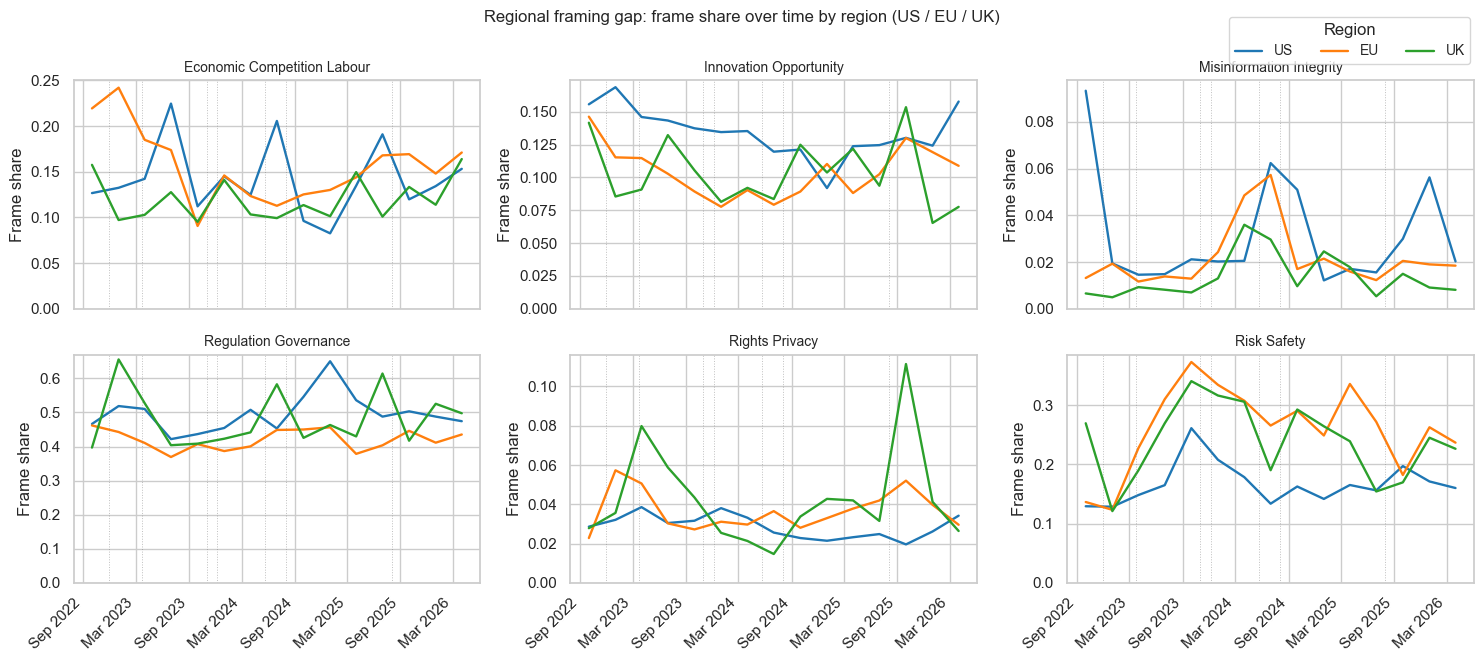

Saved fig7_regional_framing_gap.png


In [4]:
REGIONS = ['US', 'EU', 'UK']
FREQ = 'Q'
region_colors = {'US': '#1f77b4', 'EU': '#ff7f0e', 'UK': '#2ca02c'}

panel = region_frame_shares_over_time(df_raw, regions=REGIONS, freq=FREQ)
frames = list(panel['frame'].unique())

ncols = 3
nrows = int(np.ceil(len(frames) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.3 * nrows), sharex=True)
axes = np.atleast_1d(axes).flatten()

for i, frame in enumerate(frames):
    ax = axes[i]
    sub = panel[panel['frame'] == frame]
    for region in REGIONS:
        s = sub[sub['region'] == region].set_index('period')['share'].sort_index()
        if s.empty:
            continue
        ax.plot(s.index.to_timestamp(), s.values, label=region,
                color=region_colors.get(region), linewidth=1.7)
    for _name, ts in MILESTONE_DATES.items():
        ax.axvline(ts, color='grey', linestyle=':', linewidth=0.7, alpha=0.5)
    ax.set_title(frame.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Frame share')
    ax.set_ylim(bottom=0)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)
        tick.set_ha('right')

for j in range(len(frames), len(axes)):
    axes[j].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', ncol=3, fontsize=10,
           title='Region', bbox_to_anchor=(0.99, 1.0))
fig.suptitle('Regional framing gap: frame share over time by region (US / EU / UK)',
             fontsize=12, y=1.0)
plt.tight_layout()
plt.savefig(FIGURES / 'fig7_regional_framing_gap.png', bbox_inches='tight')
plt.show()
print('Saved fig7_regional_framing_gap.png')

## Pooled framing gap (whole corpus)

A negative `gap_US_EU` for `regulation_governance` means EU coverage is *more*
regulation-framed than US coverage; positive means the US leans into that frame more.

In [5]:
# Pooled whole-corpus frame share per region + pairwise gaps (percentage points)
summary = regional_gap_summary(df_raw, regions=REGIONS)
print('Overall frame share by region and pairwise gaps (percentage points):')
print((summary * 100).round(1).to_string())

Overall frame share by region and pairwise gaps (percentage points):
region                         EU    UK    US  gap_US_EU  gap_US_UK  gap_EU_UK
innovation_opportunity        9.8   9.9  13.1        3.3        3.2       -0.1
risk_safety                  28.7  23.9  16.9      -11.8       -7.0        4.7
regulation_governance        41.5  49.2  50.5        9.0        1.3       -7.7
rights_privacy                3.5   4.1   2.9       -0.6       -1.3       -0.6
economic_competition_labour  14.3  11.5  13.9       -0.4        2.3        2.7
misinformation_integrity      2.3   1.4   2.8        0.5        1.4        0.9
